# Step 1. 데이터 수집 (워밍업 2014-01 ~ 분석 2016-01 ~ 2025-12)

Final Project 프로젝트의 첫 단계로, **30개 투자 자산 + 6개 외부 지표 + 10개 대안데이터**를 수집합니다.

> **워밍업 기간 설계**: 파생변수(claims_zscore 등)의 롤링 윈도우(최대 260일)를 안정화하기 위해
> 데이터는 **2014-01-01**부터 수집하고, 실제 분석은 **2016-01-01**부터 수행합니다.

> **ETH-USD 제거 (2026-04 업데이트)**: yfinance에서 ETH-USD는 2015-08-07부터 데이터가 있어
> 워밍업 기간(2014-01~2015-08)에 결측이 발생하고, 후속 단계(HMM/Config C)에서 사용되지 않으므로
> 외부 지표에서 제거했습니다. BTC-USD는 2014-09부터 데이터 확보 + 암호화폐 관찰 지표로 유지합니다.

---

## 데이터 구성 요약

| 구분 | 개수 | 소스 | 역할 |
|------|------|------|------|
| 인덱스 ETF | 5 | yfinance | 자산군 대표 (미국대형/기술/소형/선진/신흥) |
| 채권 ETF | 4 | yfinance | 듀레이션 스펙트럼 (장기/종합/단기/물가연동) |
| 대안 ETF | 2 | yfinance | 금 + 원자재 바스켓 |
| 섹터 ETF | 11 | yfinance | GICS 11개 전 섹터 |
| 개별 종목 | 8 | yfinance | 섹터별 시총 1위 (초기 고정, 이후 Step3에서 재구성) |
| 외부 지표 | 6 | yfinance | 원유/금/은/BTC/VIX/달러 (ETH 제거) |
| 대안 원시 | 5 | yfinance | VIX9D/VIX3M/VIX6M/SKEW/구리 |
| 대안 FRED | 3 | FRED | HY스프레드/수익률곡선/실업수당 |
| 기존 FRED | 3 | FRED | 10Y금리/CPI/실업률 |

In [1]:
# ============================================================
# 라이브러리 임포트
# ============================================================
import pandas as pd
import numpy as np
import yfinance as yf
import os, warnings, time

warnings.filterwarnings('ignore')

# ── 경로 설정 ──
V3_DIR   = os.getcwd()  # Final_Project/
DATA_DIR = os.path.join(V3_DIR, 'data')
IMG_DIR  = os.path.join(V3_DIR, 'images')
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

# ── 기간 설정 ──────────────────────────────────────────────────
# WARMUP_START : 파생변수 롤링 윈도우 안정화를 위한 사전 수집 시작일
#   - claims_zscore : 260일 롤링 (가장 긴 윈도우, 약 1년 필요)
#   - SKEW_zscore   : 63일 롤링
#   - Cu_Au_ratio_chg, rv_neutral : 21일 롤링
#   → 2014-01-01 시작 시 2016-01-01 기준 약 504 거래일 확보 (260일의 2배)
# ANALYSIS_START : 실제 분석 시작일 (Step2에서 슬라이싱 기준으로 사용)
# BTC-USD 주의 : 2014-09 이후 데이터 존재 → 워밍업 8개월만 결측, ffill로 무해
WARMUP_START   = '2014-01-01'
ANALYSIS_START = '2016-01-01'
END            = '2025-12-31'

print(f'데이터 수집 : {WARMUP_START} ~ {END} (워밍업 포함)')
print(f'실제 분석   : {ANALYSIS_START} ~ {END}')
print(f'저장 경로   : {DATA_DIR}')

데이터 수집 : 2014-01-01 ~ 2025-12-31 (워밍업 포함)
실제 분석   : 2016-01-01 ~ 2025-12-31
저장 경로   : C:\Users\gorhk\최종프로젝트\finance_project\김재천\Guide\data


In [2]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()  # .env 파일 로드
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])


---
## 1-1. 투자 자산 정의 (30개)

### 인덱스 ETF (5개) — 자산군 대표
| 티커 | 자산군 | 역할 |
|------|--------|------|
| SPY | 미국 대형주 | S&P 500 대표, Level 1 주식 대표 |
| QQQ | 미국 기술주 | NASDAQ-100, 성장주 노출 |
| IWM | 미국 소형주 | Russell 2000, 내수 경기 민감 |
| EFA | 선진국 주식 | MSCI EAFE (유럽/일본), 지역 분산 |
| EEM | 신흥국 주식 | MSCI EM, 달러/원자재 민감 |

### 채권 ETF (4개) — 듀레이션 스펙트럼
| 티커 | 설명 | 역할 |
|------|------|------|
| TLT | 미국 20Y+ 장기 국채 | 금리 하락 시 수혜, 위기 방어 |
| AGG | 미국 종합 채권 | 안정적 인컴, Level 1 채권 대표 |
| SHY | 미국 1-3Y 단기 국채 | 금리 상승기 방어, 변동성 최저 |
| TIP | 미국 TIPS 물가연동채 | 인플레이션 직접 헤지 |

### 대안 ETF (2개)
| 티커 | 설명 | 역할 |
|------|------|------|
| GLD | 금 ETF | 안전자산, Level 1 대안 대표 |
| DBC | 원자재 바스켓 ETF | 인플레이션 헤지, XLB와 다른 자산 클래스(선물 vs 주식) |

### 섹터 ETF (11개) — GICS 전 섹터
| 티커 | 섹터 | 비고 |
|------|------|------|
| XLK | Technology | |
| XLF | Financials | |
| XLE | Energy | |
| XLV | Healthcare | |
| VOX | Communication Services | XLC(2018) 대신 VOX(2004) 사용 |
| XLY | Consumer Discretionary | |
| XLP | Consumer Staples | |
| XLI | Industrials | |
| XLU | Utilities | |
| XLRE | Real Estate | VNQ 대신 XLRE 사용 (섹터 ETF로 통일) |
| XLB | Materials | |

### 개별 종목 (8개) — 초기 선정 (2016-01 기준 섹터별 시총 1위)
| 티커 | 섹터 | 비고 |
|------|------|------|
| AAPL | IT | 전 기간 시총 최상위 |
| MSFT | IT(2위) → 별도 | 전 기간 안정적 |
| AMZN | Consumer Disc. | |
| GOOGL | Communication | |
| JPM | Financials | |
| JNJ | Healthcare | 2023 Kenvue 분사 주의 |
| PG | Consumer Staples | |
| XOM | Energy | 2016년 시총 상위, 에너지 대표 |

1단계: BAA10Y 수집 가능성 확인


BAA10Y 범위   : 2014-01-01 ~ 2025-12-31
관측치 개수   : 3,131개
NaN 개수      : 135개
✅ 전체 기간 확보

2단계: BAMLH0A0HYM2와 BAA10Y 상관관계 (공통 3년)


공통 관측일 : 676일

기초 통계:
       HY_spread   BAA10Y
count    676.000  676.000
mean       3.365    1.692
std        0.555    0.186
min        2.590    1.360
25%        2.930    1.540
50%        3.190    1.690
75%        3.792    1.800
max        4.950    2.280

레벨 상관  : 0.774
변화 상관  : 0.642  ← 더 중요

HY/BAA 평균 비율: 1.99배

3단계: 주요 스트레스 이벤트 반응 비교 (2023~2025)
  2023-10-이스라엘-하마스          | HY Δ=+0.42%p | BAA Δ=+0.10%p
  2024-08-일본 엔캐리            | HY Δ=+0.62%p | BAA Δ=+0.17%p
  2025-04-관세 쇼크             | HY Δ=+1.19%p | BAA Δ=+0.29%p


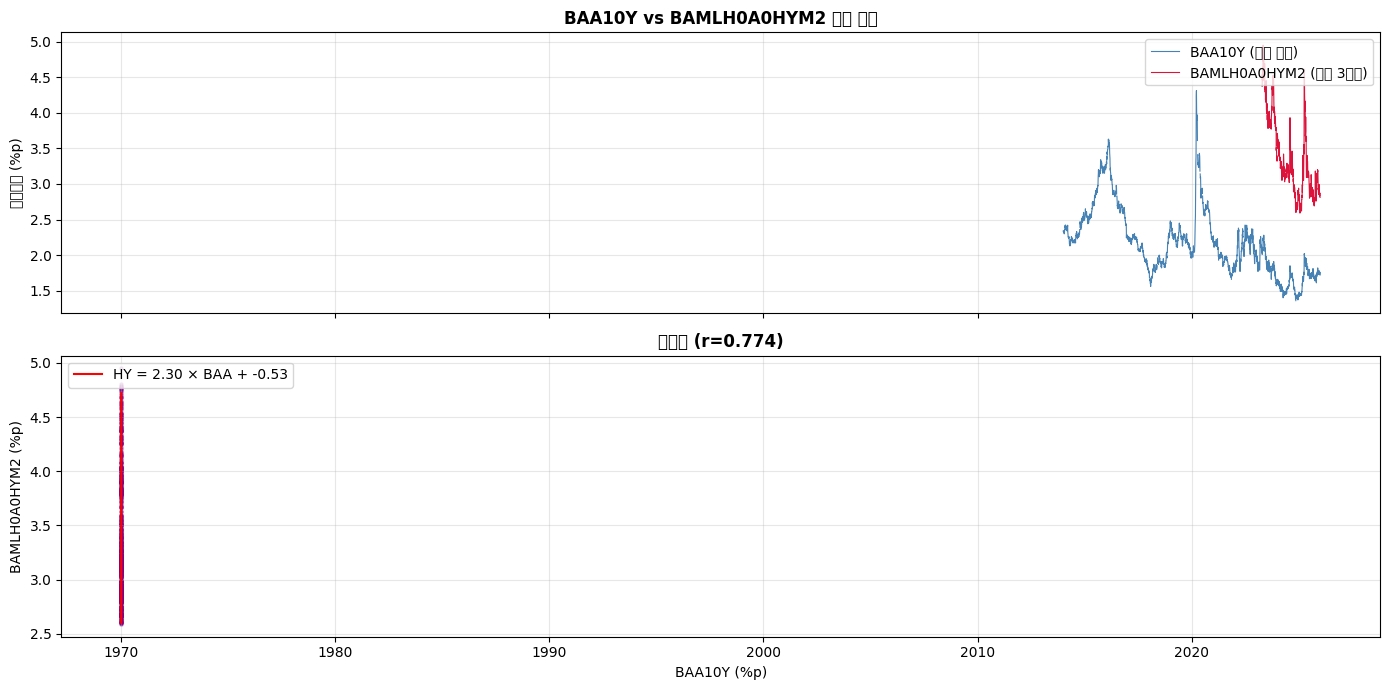


최종 판단 가이드
✅ BAA10Y 채택 조건:
   - 수집 관측치 > 2,400개 (전체 기간)
   - 변화 상관 > 0.60
   - 주요 이벤트에서 방향 일치

⚠️ 재검토 필요 조건:
   - 이벤트 반응이 일관되지 않음
   - 변화 상관 < 0.50


In [3]:
# ═══════════════════════════════════════════════════════════
# BAA10Y 실용성 검증 (3단계)
# ═══════════════════════════════════════════════════════════
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
from fredapi import Fred
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

load_dotenv(find_dotenv())
fred_client = Fred(api_key=os.environ["FRED_API_KEY"])


# ── 1단계: 수집 가능성 ─────────────────────────────────────
print('=' * 70)
print('1단계: BAA10Y 수집 가능성 확인')
print('=' * 70)
s_baa = fred_client.get_series('BAA10Y',
                                 observation_start='2014-01-01',
                                 observation_end='2025-12-31')
print(f'BAA10Y 범위   : {s_baa.index[0].date()} ~ {s_baa.index[-1].date()}')
print(f'관측치 개수   : {len(s_baa):,}개')
print(f'NaN 개수      : {s_baa.isnull().sum()}개')
print(f'✅ 전체 기간 확보' if len(s_baa) > 2400 else '⚠️ 기간 제약 있음')


# ── 2단계: BAMLH0A0HYM2와 상관관계 (공통 기간만) ───────────
print('\n' + '=' * 70)
print('2단계: BAMLH0A0HYM2와 BAA10Y 상관관계 (공통 3년)')
print('=' * 70)
s_hy = fred_client.get_series('BAMLH0A0HYM2',
                                observation_start='2023-04-18',
                                observation_end='2025-12-31')

common = pd.concat([s_hy, s_baa], axis=1).dropna()
common.columns = ['HY_spread', 'BAA10Y']

print(f'공통 관측일 : {len(common):,}일')
print(f'\n기초 통계:')
print(common.describe().round(3).to_string())

print(f'\n레벨 상관  : {common.corr().iloc[0,1]:.3f}')
print(f'변화 상관  : {common.diff().corr().iloc[0,1]:.3f}  ← 더 중요')

ratio = common['HY_spread'].mean() / common['BAA10Y'].mean()
print(f'\nHY/BAA 평균 비율: {ratio:.2f}배')


# ── 3단계: 스트레스 이벤트 반응 비교 (2023~2025) ──────────
print('\n' + '=' * 70)
print('3단계: 주요 스트레스 이벤트 반응 비교 (2023~2025)')
print('=' * 70)
events = {
    '2023-03-SVB 사태':     ('2023-03-01', '2023-03-31'),
    '2023-10-이스라엘-하마스': ('2023-10-01', '2023-10-31'),
    '2024-08-일본 엔캐리':    ('2024-08-01', '2024-08-15'),
    '2025-04-관세 쇼크':     ('2025-04-01', '2025-04-30'),
}
for name, (s, e) in events.items():
    try:
        window = common.loc[s:e]
        if len(window) == 0:
            continue
        hy_chg  = window['HY_spread'].max() - window['HY_spread'].min()
        baa_chg = window['BAA10Y'].max()  - window['BAA10Y'].min()
        print(f'  {name:25s} | HY Δ={hy_chg:+.2f}%p | BAA Δ={baa_chg:+.2f}%p')
    except KeyError:
        continue


# ── 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(s_baa.index, s_baa.values, color='steelblue', linewidth=0.8, label='BAA10Y (전체 기간)')
ax.plot(s_hy.index, s_hy.values, color='crimson', linewidth=0.8, label='BAMLH0A0HYM2 (최근 3년만)')
ax.set_ylabel('스프레드 (%p)')
ax.set_title('BAA10Y vs BAMLH0A0HYM2 수준 비교', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

ax = axes[1]
if len(common) > 0:
    ax.scatter(common['BAA10Y'], common['HY_spread'], s=5, alpha=0.4, color='purple')
    z = np.polyfit(common['BAA10Y'], common['HY_spread'], 1)
    xx = np.linspace(common['BAA10Y'].min(), common['BAA10Y'].max(), 100)
    ax.plot(xx, np.polyval(z, xx), color='red', linewidth=1.5,
            label=f'HY = {z[0]:.2f} × BAA + {z[1]:.2f}')
    ax.set_xlabel('BAA10Y (%p)')
    ax.set_ylabel('BAMLH0A0HYM2 (%p)')
    ax.set_title(f'산점도 (r={common.corr().iloc[0,1]:.3f})', fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ── 최종 판단 ─────────────────────────────────────────────
print('\n' + '=' * 70)
print('최종 판단 가이드')
print('=' * 70)
print('✅ BAA10Y 채택 조건:')
print('   - 수집 관측치 > 2,400개 (전체 기간)')
print('   - 변화 상관 > 0.60')
print('   - 주요 이벤트에서 방향 일치')
print('\n⚠️ 재검토 필요 조건:')
print('   - 이벤트 반응이 일관되지 않음')
print('   - 변화 상관 < 0.50')

In [4]:
# ============================================================
# 티커 정의
# ============================================================

# ── 투자 자산 (30개) ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX',
              'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

# 전체 투자 자산
ALL_PORTFOLIO = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS
print(f'투자 자산: {len(ALL_PORTFOLIO)}개')
print(f'  인덱스 ETF: {INDEX_ETF}')
print(f'  채권 ETF:   {BOND_ETF}')
print(f'  대안 ETF:   {ALT_ETF}')
print(f'  섹터 ETF:   {SECTOR_ETF}')
print(f'  개별 종목:  {STOCKS}')

# ── 외부 지표 (6개, 투자하지 않고 관찰만) ──
# ETH-USD 제거: (1) yfinance 2015-08 이전 데이터 없음 → 워밍업 구간 결측
#              (2) 파이프라인 후속 단계(HMM/Config C)에서 미사용
#              (3) BTC-USD만으로도 암호화폐 시장 움직임은 충분히 포착
EXTERNAL = {
    'CL=F':    'WTI 원유 선물',
    'GC=F':    '금 선물 (COMEX)',
    'SI=F':    '은 선물 (COMEX)',
    'BTC-USD': '비트코인',
    '^VIX':    'VIX (공포 지수)',
    'DX-Y.NYB':'DXY (달러 인덱스)',
}
print(f'\n외부 지표: {len(EXTERNAL)}개 — {list(EXTERNAL.keys())}')

# ── 대안데이터 yfinance (5개) ──
ALT_YF = {
    '^VIX9D': 'VIX 9-Day (초단기 내재 변동성)',
    '^VIX3M': 'VIX 3-Month (중기 내재 변동성)',
    '^VIX6M': 'VIX 6-Month (장기 내재 변동성)',
    '^SKEW':  'CBOE SKEW Index (꼬리 위험)',
    'HG=F':   'Copper Futures (구리 선물)',
}
print(f'대안 yfinance: {len(ALT_YF)}개 — {list(ALT_YF.keys())}')

# ── 대안데이터 FRED (5개) ──
ALT_FRED = {
    'BAA10Y':       'Moody Baa - 10Y 신용스프레드 (HY 대체)',  # ← 변경
    'T10Y2Y':       '10Y-2Y 수익률 곡선 스프레드',
    'ICSA':         '신규 실업수당 청구 (주간)',
    'WEI':          'Weekly Economic Index (주간)',
}

# ── 기존 FRED 매크로 (3개) ──
MACRO_FRED = {
    'DGS10':    '미국 10Y 국채 수익률',
    'CPIAUCSL': '소비자물가지수 (CPI)',
    'UNRATE':   '실업률',
}
print(f'FRED 대안: {len(ALT_FRED)}개, 기존 매크로: {len(MACRO_FRED)}개')
print(f'\n총 수집 대상: {len(ALL_PORTFOLIO) + len(EXTERNAL) + len(ALT_YF) + len(ALT_FRED) + len(MACRO_FRED)}개')

투자 자산: 30개
  인덱스 ETF: ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
  채권 ETF:   ['TLT', 'AGG', 'SHY', 'TIP']
  대안 ETF:   ['GLD', 'DBC']
  섹터 ETF:   ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
  개별 종목:  ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

외부 지표: 6개 — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', '^VIX', 'DX-Y.NYB']
대안 yfinance: 5개 — ['^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']
FRED 대안: 4개, 기존 매크로: 3개

총 수집 대상: 48개


---
## 1-2. yfinance 시세 수집

투자 자산 30개 + 외부 지표 7개 + 대안 yfinance 5개 = **42개 티커**를 수집합니다.  
각 티커를 개별적으로 수집하여, 일부 실패 시에도 나머지가 유지되도록 합니다.

### 🎯 외부 지표 처리 정책 (yfinance — 일별, lag 0)

| 그룹 | 티커 | 빈도 | 처리 | 사용처 |
|------|------|------|------|--------|
| 투자 자산 ETF/주식 | SPY, QQQ, IWM, EFA, EEM, XLK ... AAPL ... | 일별 | EOD close, ffill | Step2~ 수익률·공분산 |
| 채권/대체 ETF | TLT, AGG, SHY, TIP, GLD, DBC | 일별 | EOD close, ffill | Step2~ |
| VIX 지수군 | ^VIX, ^VIX9D, ^VIX3M, ^VIX6M | 일별 | EOD close, ffill | Step2 파생변수 (Contango 등) |
| 원자재/통화 | CL=F, GC=F, SI=F, HG=F, DX-Y.NYB | 일별 | EOD close, ffill | Step2 외부 지표 |
| 디지털 자산 | BTC-USD | 일별 | EOD close, ffill | Step2 외부 지표 |
| Skew | ^SKEW | 일별 | EOD close, ffill | Step2 파생변수 (테일 위험) |

**lag 0 정책**: yfinance EOD close는 장 마감 직후 반영되므로 발표 시차가 없는 일별 데이터로 간주.  
**SPY 실거래일 정렬**: NYSE 공휴일 자동 제외, 다른 시장(BTC-USD 365일 거래)은 SPY 일자에 맞춰 reindex + ffill.  
**워밍업**: 워밍업 기간 중 후발 상장 자산(BTC-USD 2014-09 등)은 분석 시작일(2016-01-01) 이전 NaN 가능 — 분석 슬라이싱 시 제거됨.

In [5]:
# ============================================================
# yfinance 일괄 수집 (41개 티커) — WARMUP_START 부터 수집
# ============================================================
# 수집 구성: 투자 자산 30 + 외부 지표 6 + 대안 yfinance 5 = 41개
# (ETH-USD 제거: 2015-08 이전 데이터 없음 + 후속 단계 미사용)

all_yf_tickers = ALL_PORTFOLIO + list(EXTERNAL.keys()) + list(ALT_YF.keys())
print(f'yfinance 수집 대상: {len(all_yf_tickers)}개 티커')
print(f'수집 기간: {WARMUP_START} ~ {END} (워밍업 포함)\n')

# 개별 수집 (안정성 우선)
yf_data = {}
failed  = []

for i, ticker in enumerate(all_yf_tickers, 1):
    try:
        # WARMUP_START 부터 수집 (2014-01-01)
        df = yf.download(ticker, start=WARMUP_START, end=END,
                         auto_adjust=True, progress=False)
        if df.empty:
            print(f'  [{i:2d}/{len(all_yf_tickers)}] [WARN] {ticker:12s} — 데이터 없음')
            failed.append(ticker)
            continue
        # Close 가격 추출 (MultiIndex 대응)
        if isinstance(df.columns, pd.MultiIndex):
            series = df[('Close', ticker)].dropna()
        else:
            series = df['Close'].dropna()
        yf_data[ticker] = series
        if i % 10 == 0 or i == len(all_yf_tickers):
            print(f'  [{i:2d}/{len(all_yf_tickers)}] {ticker:12s} — {len(series):,}일 수집 완료')
    except Exception as e:
        print(f'  [{i:2d}/{len(all_yf_tickers)}] [ERR] {ticker:12s} — {e}')
        failed.append(ticker)

# BTC-USD 최초 거래일 확인 (암호화폐 관찰 지표로 유지)
if 'BTC-USD' in yf_data:
    print(f'\nBTC-USD 최초 거래일: {yf_data["BTC-USD"].first_valid_index().date()}')

print(f'\n수집 완료: {len(yf_data)}개 성공, {len(failed)}개 실패')
if failed:
    print(f'실패 티커: {failed}')

yfinance 수집 대상: 41개 티커
수집 기간: 2014-01-01 ~ 2025-12-31 (워밍업 포함)



  [10/41] GLD          — 3,017일 수집 완료


  [20/41] XLU          — 3,017일 수집 완료


  [30/41] XOM          — 3,017일 수집 완료


  [40/41] ^SKEW        — 2,960일 수집 완료


  [41/41] HG=F         — 3,017일 수집 완료

BTC-USD 최초 거래일: 2014-09-17

수집 완료: 41개 성공, 0개 실패


In [6]:
# ============================================================
# DataFrame 병합 + SPY 실거래일 기준 정렬
# ============================================================

# 전체 DataFrame 구성
df_all_prices = pd.DataFrame(yf_data)
df_all_prices.index = pd.to_datetime(df_all_prices.index)
df_all_prices = df_all_prices.sort_index()

# ── 수정 1: SPY 실거래일을 기준 인덱스로 사용 ──────────────────
# pd.bdate_range(freq='B')는 NYSE 공휴일(MLK Day, Good Friday 등)을 포함해 잘못된 인덱스 생성
# SPY는 NYSE 상장 ETF이므로 SPY.dropna().index = 실제 NYSE 영업일
spy_trading_days = yf_data['SPY'].dropna().index
df_all_prices = df_all_prices.reindex(spy_trading_days)

# ── 수정 2: ffill() 단독 사용, bfill() 제거 ────────────────────
# ffill  : 직전 종가 유지 ("공휴일엔 가격 불변") → 경제적으로 합리적
# bfill  : 미래값으로 과거 채움 → look-ahead bias 발생, 사용 금지
df_all_prices = df_all_prices.ffill()

# 맨 앞 NaN 행 제거 (ffill로 채울 이전 데이터가 없는 시작 구간)
df_all_prices = df_all_prices.dropna(how='all')
df_all_prices.index.name = 'Date'

print(f'전체 시세 DataFrame : {df_all_prices.shape}')
print(f'기간 : {df_all_prices.index[0].date()} ~ {df_all_prices.index[-1].date()}')
print(f'  (워밍업 포함: {WARMUP_START} ~ {END})')
print(f'\n결측률:')
missing = df_all_prices.isnull().sum()
if missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(missing[missing > 0])

전체 시세 DataFrame : (3017, 41)
기간 : 2014-01-02 ~ 2025-12-30
  (워밍업 포함: 2014-01-01 ~ 2025-12-31)

결측률:
XLRE       445
BTC-USD    178
dtype: int64


In [7]:
# ============================================================
# 투자 자산과 외부/대안 지표 분리 저장
# ============================================================

# 투자 자산 (30개) — 실제 매매 대상
port_cols = [c for c in ALL_PORTFOLIO if c in df_all_prices.columns]
df_portfolio = df_all_prices[port_cols]

# 외부 지표 + 대안 yfinance (12개) — 관찰만
ext_alt_cols = [c for c in list(EXTERNAL.keys()) + list(ALT_YF.keys()) if c in df_all_prices.columns]
df_ext_alt = df_all_prices[ext_alt_cols]

print(f'투자 자산: {df_portfolio.shape} — {list(df_portfolio.columns)}')
print(f'외부+대안: {df_ext_alt.shape} — {list(df_ext_alt.columns)}')

투자 자산: (3017, 30) — ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'AGG', 'SHY', 'TIP', 'GLD', 'DBC', 'XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']
외부+대안: (3017, 11) — ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', '^VIX', 'DX-Y.NYB', '^VIX9D', '^VIX3M', '^VIX6M', '^SKEW', 'HG=F']


In [8]:
df_portfolio.head()

,SPY,QQQ,IWM,EFA,EEM,TLT,AGG,SHY,TIP,GLD,...,XLRE,XLB,AAPL,MSFT,AMZN,GOOGL,JPM,JNJ,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-02,148.580231,79.043633,97.359772,46.040524,30.777201,73.026146,76.418907,68.749443,81.328362,118.000000,...,NaN,17.937414,17.140667,30.760921,19.898500,27.627514,41.982841,64.870247,57.018673,60.117630
2014-01-03,148.555908,78.473015,97.854630,46.089420,30.723597,73.026146,76.447639,68.725037,81.291458,119.290001,...,NaN,17.894381,16.764162,30.553972,19.822001,27.425978,42.307404,65.454575,56.954941,59.972992
2014-01-06,148.125427,78.183197,97.061127,46.033543,30.432602,73.333527,76.548088,68.733246,81.564377,119.500000,...,NaN,17.796572,16.855568,29.908289,19.681499,27.731758,42.552616,65.796631,57.089470,60.063396
2014-01-07,149.035095,78.907784,97.871651,46.291988,30.562780,73.519325,76.583931,68.733246,81.579170,118.820000,...,NaN,17.765285,16.735023,30.140074,19.901501,28.266380,42.062199,67.193382,57.641685,60.913185
2014-01-08,149.067657,79.079880,97.999664,46.278030,30.463213,73.319176,76.354309,68.668068,81.527512,118.120003,...,NaN,17.870907,16.841005,29.601994,20.096001,28.325203,42.458858,67.100723,56.806278,60.714283


In [9]:
df_ext_alt.head()

,CL=F,GC=F,SI=F,BTC-USD,^VIX,DX-Y.NYB,^VIX9D,^VIX3M,^VIX6M,^SKEW,HG=F
Date,,,,,,,,,,,
2014-01-02,95.440002,1225.000000,20.098000,NaN,14.23,80.629997,13.83,15.26,16.740000,133.729996,3.4315
2014-01-03,93.959999,1238.400024,20.181999,NaN,13.76,80.790001,12.17,15.09,16.680000,134.460007,3.4060
2014-01-06,93.430000,1237.800049,20.077000,NaN,13.55,80.650002,12.51,14.82,16.459999,131.990005,3.4120
2014-01-07,93.669998,1229.400024,19.764999,NaN,12.92,80.830002,11.57,14.41,15.980000,129.100006,3.4110
2014-01-08,92.330002,1225.300049,19.518000,NaN,12.87,81.040001,11.62,14.29,15.940000,129.460007,3.3935


---
## 1-3. FRED 데이터 수집 — PIT (Point-In-Time) 방식

FRED에서 **8개 시리즈**를 수집합니다 (대안 5개 + 기존 매크로 3개).

### 🎯 PIT 적용 (2026-04 업데이트)

기존 `get_series()`는 **관측 일자(observation date)** 만 반환 → 실제 발표일과 괴리 발생 →
백테스트에 **look-ahead bias** 유입.

**해결 — 하이브리드 방식**:

| 시리즈 | 빈도 | 처리 방식 | 이유 |
|--------|------|---------|------|
| `DGS10`, `T10Y2Y` | 일별 | observation + lag 0 | 당일 EOD 즉시 발표 |
| `BAA10Y` | 일별 | observation + lag 1일 | 익일 아침 발표 |
| `ICSA`, `WEI` | 주간 | **ALFRED vintage PIT** | 매주 전주값 재수정 |
| `CPIAUCSL`, `UNRATE` | 월간 | **ALFRED vintage PIT** | 월 30~45일 발표 지연 + 다수 수정 |

### Vintage PIT 원리

각 거래일 T에 대해 **"T 시점까지 발표된 관측치 중 가장 최근 발표(realtime_start)의 값"** 을 사용.  
속보치 → 잠정치 → 확정치 → benchmark 수정까지 **모두 반영**.

### 정렬

주간/월간 데이터는 **달력일 기준 ffill 후 SPY 실거래일 필터**로 정렬합니다.  
(PIT 적용 후 발표일 기준으로 값이 존재하므로, 다음 발표 전까지 ffill)

In [10]:
# ============================================================
# FRED 수집 — 하이브리드 PIT (2026-04 업데이트)
# ============================================================
# 
# 목적: 관측일(observation date) → 발표일(publication date) 기준으로 전환
#       → 백테스트 look-ahead bias 제거
#
# 두 가지 방식 혼합:
#   1) 일별 시리즈 (DGS10, T10Y2Y, BAA10Y): observation + 하드코딩 lag
#      - ALFRED vintage API 상한(약 2,000개) 초과로 실패
#      - 발표 시차가 0~1일로 미미 → lag만으로 충분
#   2) 주간·월간 시리즈 (ICSA, WEI, CPIAUCSL, UNRATE): ALFRED vintage
#      - 다수 수정 발생 (최대 21배) → 완전 PIT 필요
#      - 각 거래일 T에 "T 시점까지 발표된 가장 최근 관측치의 latest value"

from fredapi import Fred
import pandas as pd

fred_client = Fred(api_key=os.environ["FRED_API_KEY"])

# ── 변수별 처리 방식 지정 ──
FRED_LAG_DAYS = {       # 일별 시리즈: observation + 발표 시차
    'DGS10':  0,        # 당일 EOD 발표
    'T10Y2Y': 0,        # 당일 EOD 발표
    'BAA10Y': 1,        # 익일 아침 발표
}

FRED_VINTAGE = [        # 주간·월간 시리즈: ALFRED vintage PIT
    'ICSA',
    'WEI',
    'CPIAUCSL',
    'UNRATE',
]


def get_fred_lagged(series_id: str, start: str, end: str, lag_days: int = 0) -> pd.Series:
    """일별 시리즈: observation + 발표 시차 적용."""
    s = fred_client.get_series(
        series_id,
        observation_start=start,
        observation_end=end,
    )
    if lag_days > 0:
        # 관측 일자를 발표 일자로 이동 (미래로 shift)
        s.index = s.index + pd.Timedelta(days=lag_days)
    s.name = series_id
    return s.dropna()


def get_fred_pit(series_id: str, start: str, end: str) -> pd.Series:
    """
    ALFRED vintage 기반 PIT 재구성 (asof-merge 최적화).
    
    각 거래일 T에 대해:
      1) T 시점까지 발표된(realtime_start ≤ T) 모든 vintage 수집
      2) Running snapshot 유지: obs_date → 최신 발표값
      3) snapshot에서 "가장 최근 obs_date"의 값을 T의 PIT 값으로 할당
    
    → 속보치·잠정치·확정치·benchmark 수정 모두 정확히 반영
    """
    all_rel = fred_client.get_series_all_releases(series_id)
    all_rel = all_rel.dropna(subset=['value']).copy()
    all_rel['realtime_start'] = pd.to_datetime(all_rel['realtime_start'])
    all_rel['date']           = pd.to_datetime(all_rel['date'])
    
    # 발표일(realtime_start) 오름차순
    all_rel = all_rel.sort_values(['realtime_start', 'date']).reset_index(drop=True)
    
    # numpy 배열 사용 → 반복 루프 가속
    rts  = all_rel['realtime_start'].values
    dts  = all_rel['date'].values
    vals = all_rel['value'].values
    
    snapshot     = {}                       # obs_date → latest known value
    latest_obs   = pd.Timestamp.min.to_numpy()
    timeline_rt  = []
    timeline_val = []
    
    for rt, obs_date, value in zip(rts, dts, vals):
        snapshot[obs_date] = value
        if obs_date > latest_obs:
            latest_obs = obs_date
        timeline_rt.append(rt)
        timeline_val.append(snapshot[latest_obs])
    
    # 같은 발표일 내 중복은 마지막 값만
    timeline_df = pd.DataFrame({
        'realtime_start': timeline_rt,
        'value':          timeline_val,
    }).groupby('realtime_start', as_index=False).last()
    timeline_df['realtime_start'] = pd.to_datetime(timeline_df['realtime_start'])
    timeline_df = timeline_df.sort_values('realtime_start').reset_index(drop=True)
    
    # asof-merge로 달력일에 매핑 (backward: rt ≤ T)
    daily = pd.date_range(start=start, end=end, freq='D')
    daily_df = pd.DataFrame({'realtime_start': daily})
    result = pd.merge_asof(
        daily_df, timeline_df,
        on='realtime_start',
        direction='backward',
    )
    
    s = pd.Series(result['value'].values, index=daily, name=series_id)
    return s.dropna()


# ── 8개 시리즈 수집 ──
ALL_FRED = {**ALT_FRED, **MACRO_FRED}  # 5 + 3 = 8개
fred_data = {}

print('=' * 75)
print('FRED 수집 (하이브리드 PIT)')
print('=' * 75)

for series_id, desc in ALL_FRED.items():
    try:
        if series_id in FRED_VINTAGE:
            # 주간·월간 → ALFRED vintage PIT
            s = get_fred_pit(series_id, WARMUP_START, END)
            method = 'vintage-PIT'
        else:
            # 일별 → observation + 시차
            lag = FRED_LAG_DAYS.get(series_id, 0)
            s = get_fred_lagged(series_id, WARMUP_START, END, lag_days=lag)
            method = f'obs+lag{lag}d'
        
        fred_data[series_id] = s
        print(f'  [OK] {series_id:15s} ({method:11s}) — {len(s):>5,}개')
    except Exception as e:
        print(f'  [ERR] {series_id:15s} — {str(e)[:60]}')

df_fred_raw = pd.DataFrame(fred_data)
df_fred_raw.index = pd.to_datetime(df_fred_raw.index)
print(f'\nFRED 원시: {df_fred_raw.shape}')
print(f'기간: {df_fred_raw.index[0].date()} ~ {df_fred_raw.index[-1].date()}')

FRED 수집 (하이브리드 PIT)


  [OK] BAA10Y          (obs+lag1d  ) — 2,996개


  [OK] T10Y2Y          (obs+lag0d  ) — 3,000개


  [OK] ICSA            (vintage-PIT) — 4,383개


  [OK] WEI             (vintage-PIT) — 2,086개


  [OK] DGS10           (obs+lag0d  ) — 3,000개


  [OK] CPIAUCSL        (vintage-PIT) — 4,383개


  [OK] UNRATE          (vintage-PIT) — 4,383개

FRED 원시: (4384, 7)
기간: 2014-01-01 ~ 2026-01-01


In [11]:
df_fred_raw.head(20)


,BAA10Y,T10Y2Y,ICSA,WEI,DGS10,CPIAUCSL,UNRATE
2014-01-01,NaN,NaN,338000.0,NaN,NaN,233.887,7.0
2014-01-02,NaN,2.61,339000.0,NaN,3.00,233.887,7.0
2014-01-03,2.34,2.60,339000.0,NaN,3.01,233.887,7.0
2014-01-04,2.34,NaN,339000.0,NaN,NaN,233.887,7.0
2014-01-05,NaN,NaN,339000.0,NaN,NaN,233.887,7.0
2014-01-06,NaN,2.58,339000.0,NaN,2.98,233.887,7.0
2014-01-07,2.32,2.56,339000.0,NaN,2.96,233.887,7.0
2014-01-08,2.32,2.58,339000.0,NaN,3.01,233.887,7.0
2014-01-09,2.31,2.53,330000.0,NaN,2.97,233.887,7.0
2014-01-10,2.31,2.49,330000.0,NaN,2.88,233.887,6.7


In [12]:
# # ============================================================
# # FRED 수집 (8개 시리즈) — CSV URL 방식 (fredapi 미설치 환경용)
# # ============================================================

# def get_fred(series_id: str, start: str, end: str) -> pd.Series:
#     url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
#     df = pd.read_csv(url, index_col=0, parse_dates=True)
#     df.columns = [series_id]
#     return df.loc[start:end, series_id].dropna()

# ALL_FRED = {**ALT_FRED, **MACRO_FRED}  # 5 + 3 = 8개
# fred_data = {}

# for series_id, desc in ALL_FRED.items():
#     try:
#         # WARMUP_START 부터 수집 (2014-01-01)
#         s = get_fred(series_id, WARMUP_START, END)
#         fred_data[series_id] = s
#         print(f'  [OK] {series_id:20s} ({desc}) — {len(s):,}개 관측치')
#     except Exception as e:
#         print(f'  [ERR] {series_id:20s} ({desc}) — {e}')

# df_fred_raw = pd.DataFrame(fred_data)
# df_fred_raw.index = pd.to_datetime(df_fred_raw.index)
# print(f'\nFRED 원시: {df_fred_raw.shape}')

In [13]:
# ============================================================
# FRED → 달력일 ffill → SPY 실거래일 필터
# ============================================================
#
# 이 단계의 역할 (PIT 적용 후에도 유지):
#   - PIT 처리 후에도 주간/월간 변수는 달력일 중 "발표일"에만 값 존재
#   - 달력일 기준으로 ffill → 다음 발표 전까지 값 유지
#   - 그 후 SPY 실거래일만 필터 (NYSE 공휴일 자동 제외)
#
# 이전 수정 사항 (유지):
#   - bfill() 제거 → look-ahead bias 차단
#   - spy_trading_days 인덱스 사용 → NYSE 공휴일 정확 반영
#
# PIT 적용 후 특성:
#   - DGS10, T10Y2Y, BAA10Y: 이미 일별 데이터 (lag 적용) → reindex 영향 미미
#   - ICSA, WEI: 목요일 발표 기준 값 → 다음 목요일 전까지 ffill
#   - CPIAUCSL, UNRATE: 월 발표일 기준 → 다음 발표 전까지 ffill

daily_range = pd.date_range(start=WARMUP_START, end=END, freq='D')
df_fred_daily = df_fred_raw.reindex(daily_range).ffill()
df_fred = df_fred_daily.reindex(spy_trading_days)
df_fred.index.name = 'Date'

print(f'FRED 정렬 후: {df_fred.shape}')
print(f'결측률:')
fred_missing = df_fred.isnull().sum()
if fred_missing.sum() == 0:
    print('  전 컬럼 결측 0개')
else:
    print(fred_missing[fred_missing > 0])
    print('\n  (주의: PIT 적용 시 초기 기간은 "아직 발표되지 않음" → NaN 자연 발생)')

FRED 정렬 후: (3017, 7)
결측률:
BAA10Y       1
WEI       1582
dtype: int64

  (주의: PIT 적용 시 초기 기간은 "아직 발표되지 않음" → NaN 자연 발생)


---
## 1-4. 데이터 검증 + 기초 통계

수집된 데이터의 품질을 확인합니다.

In [14]:
# ============================================================
# 전체 결측률 리포트
# ============================================================

all_data = pd.concat([df_all_prices, df_fred], axis=1)
total = len(all_data)

report = pd.DataFrame({
    '컬럼': all_data.columns,
    '총 행수': total,
    '결측 수': all_data.isnull().sum().values,
    '결측률(%)': (all_data.isnull().sum().values / total * 100).round(2),
})

# 결측 있는 것만 출력 (없으면 "전부 0" 메시지)
has_missing = report[report['결측 수'] > 0]
if len(has_missing) == 0:
    print(f'=== 전체 {len(all_data.columns)}개 컬럼, 결측 0개 ===')
else:
    print('=== 결측 존재 컬럼 ===')
    print(has_missing.to_string(index=False))

print(f'\n총 데이터: {all_data.shape[0]}일 × {all_data.shape[1]}개 컬럼')
print(f'기간: {all_data.index[0].date()} ~ {all_data.index[-1].date()}')

=== 결측 존재 컬럼 ===
     컬럼  총 행수  결측 수  결측률(%)
   XLRE  3017   445   14.75
BTC-USD  3017   178    5.90
 BAA10Y  3017     1    0.03
    WEI  3017  1582   52.44

총 데이터: 3017일 × 48개 컬럼
기간: 2014-01-02 ~ 2025-12-30


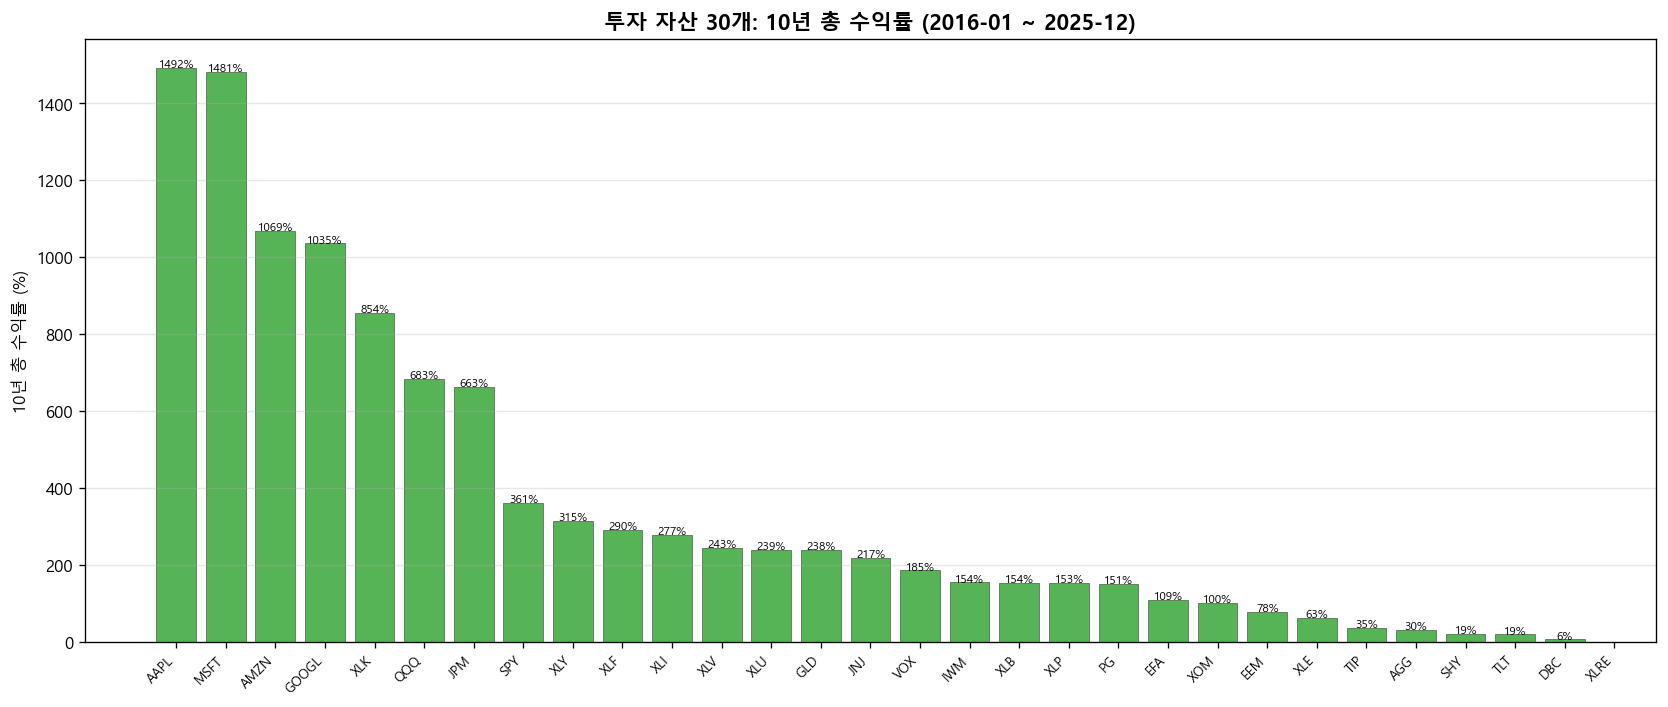

저장: images/step1_01_total_returns.png


In [15]:
# ============================================================
# 투자 자산 기초 통계 (시작/종료 가격, 10년 수익률)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 10년 총 수익률
total_ret = (df_portfolio.iloc[-1] / df_portfolio.iloc[0] - 1) * 100
total_ret = total_ret.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in total_ret]
bars = ax.bar(range(len(total_ret)), total_ret, color=colors, alpha=0.8, edgecolor='black', linewidth=0.3)
ax.set_xticks(range(len(total_ret)))
ax.set_xticklabels(total_ret.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('10년 총 수익률 (%)')
ax.set_title('투자 자산 30개: 10년 총 수익률 (2016-01 ~ 2025-12)', fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# 값 라벨
for bar, val in zip(bars, total_ret):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + (2 if y >= 0 else -8),
            f'{val:.0f}%', ha='center', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_01_total_returns.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_01_total_returns.png')

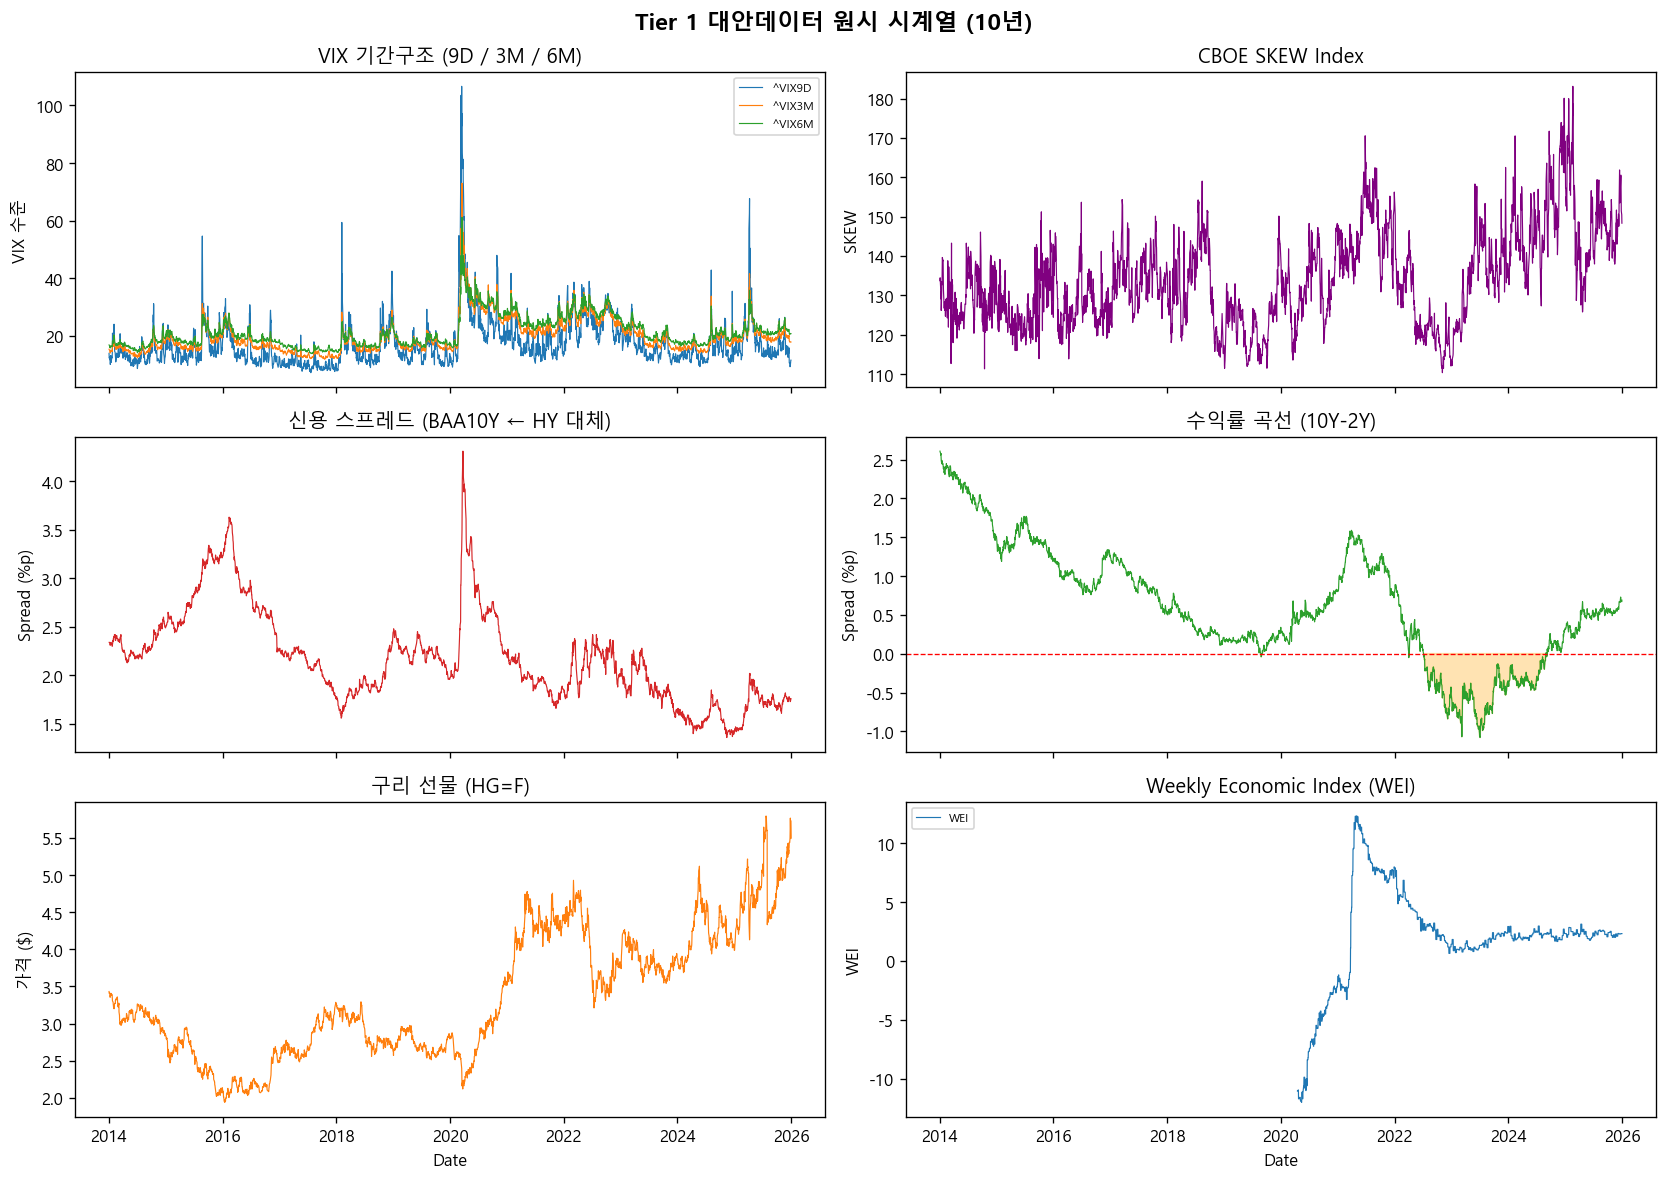

저장: images/step1_02_alt_data_preview.png


In [16]:
# ============================================================
# 대안데이터 시계열 미리보기
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
fig.suptitle('Tier 1 대안데이터 원시 시계열 (10년)', fontsize=14, fontweight='bold')

# VIX 기간구조
ax = axes[0, 0]
for t in ['^VIX9D', '^VIX3M', '^VIX6M']:
    if t in df_ext_alt.columns:
        ax.plot(df_ext_alt.index, df_ext_alt[t], linewidth=0.7, label=t)
ax.set_title('VIX 기간구조 (9D / 3M / 6M)')
ax.legend(fontsize=7)
ax.set_ylabel('VIX 수준')

# SKEW
ax = axes[0, 1]
if '^SKEW' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['^SKEW'], linewidth=0.7, color='purple')
ax.set_title('CBOE SKEW Index')
ax.set_ylabel('SKEW')

# 신용 스프레드 (BAA10Y ← BAMLH0A0HYM2 대체, ICE 라이선스 3년 제약)
ax = axes[1, 0]
ax.plot(df_fred.index, df_fred['BAA10Y'], linewidth=0.7, color='#d62728')
ax.set_title('신용 스프레드 (BAA10Y ← HY 대체)')
ax.set_ylabel('Spread (%p)')

# 수익률 곡선
ax = axes[1, 1]
ax.plot(df_fred.index, df_fred['T10Y2Y'], linewidth=0.7, color='#2ca02c')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.fill_between(df_fred.index, df_fred['T10Y2Y'], 0,
                where=df_fred['T10Y2Y'] < 0, color='orange', alpha=0.3)
ax.set_title('수익률 곡선 (10Y-2Y)')
ax.set_ylabel('Spread (%p)')

# 구리 선물
ax = axes[2, 0]
if 'HG=F' in df_ext_alt.columns:
    ax.plot(df_ext_alt.index, df_ext_alt['HG=F'], linewidth=0.7, color='#ff7f0e')
ax.set_title('구리 선물 (HG=F)')
ax.set_ylabel('가격 ($)')
ax.set_xlabel('Date')

# Weekly Economic Index (실물경기 nowcast)
# TODO(v5): 추가 실물경기 트리거 검토 (UNRATE z-score, claims_zscore 등)
ax = axes[2, 1]
ax.plot(df_fred.index, df_fred['WEI'], linewidth=0.7, color='#1f77b4', label='WEI')
ax.set_title('Weekly Economic Index (WEI)')
ax.set_ylabel('WEI')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=7)

plt.tight_layout()
fig.savefig(os.path.join(IMG_DIR, 'step1_02_alt_data_preview.png'), bbox_inches='tight')
plt.show()
print('저장: images/step1_02_alt_data_preview.png')

---
## 1-5. CSV 저장

이후 Step에서 사용할 CSV 파일을 저장합니다.

| 파일 | 내용 | 사용처 |
|------|------|--------|
| portfolio_prices.csv | 투자 자산 30개 일별 종가 | Step2~7 전체 |
| external_prices.csv | 외부 지표 + 대안 yfinance 12개 | Step2 피처 엔지니어링 |
| fred_data.csv | FRED 8개 시리즈 | Step2 피처 엔지니어링 |

In [17]:
# ============================================================
# CSV 저장
# ============================================================

saves = {
    'portfolio_prices.csv': df_portfolio,
    'external_prices.csv': df_ext_alt,
    'fred_data.csv': df_fred,
}

print('=== CSV 저장 ===')
for fname, df in saves.items():
    path = os.path.join(DATA_DIR, fname)
    df.to_csv(path)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:30s} | {df.shape[0]:,}행 × {df.shape[1]:,}열 | {size_kb:.0f} KB')

print(f'\n저장 경로: {DATA_DIR}')
print('Step1 완료.')

=== CSV 저장 ===
  portfolio_prices.csv           | 3,017행 × 30열 | 1639 KB
  external_prices.csv            | 3,017행 × 11열 | 606 KB
  fred_data.csv                  | 3,017행 × 7열 | 150 KB

저장 경로: C:\Users\gorhk\최종프로젝트\finance_project\김재천\Guide\data
Step1 완료.


## 1-6. 워밍업 정책 가드 (assert)

분석 시작일(2016-01-01) 이후 잔존 NaN을 자동 검증.
- `portfolio_prices`, `external_prices`, `features`: 0 NaN 기대
- `fred_data`: WEI(2020-04 신설)는 의도된 NaN — 화이트리스트 처리


In [18]:
# ============================================================
# 1-6. 워밍업 정책 검증 (analysis-start NaN gate)
# ============================================================
# 의도: 2014-01-01 워밍업 데이터가 2016-01-01 이후 분석 결과를 오염시키지 않도록
#       슬라이싱 후 잔존 NaN을 명시적으로 검증.
ANALYSIS_START = '2016-01-01'

# WEI는 2020-04 신설이라 그 이전은 의도된 NaN — 검증 시 화이트리스트
ALLOWED_NAN_COLS = {'WEI'}

def assert_no_unexpected_nan(name, df, allowed=ALLOWED_NAN_COLS):
    sub = df.loc[ANALYSIS_START:]
    nan_per_col = sub.isna().sum()
    bad = nan_per_col[nan_per_col > 0].index.difference(allowed)
    if len(bad) > 0:
        raise AssertionError(
            f'[{name}] {ANALYSIS_START} 이후 NaN이 화이트리스트({allowed})에 없는 컬럼에 존재: '
            f'{dict((c, int(nan_per_col[c])) for c in bad)}'
        )
    msg = f'  {name}: OK ({len(sub):,}행)'
    if any(c in allowed for c in nan_per_col[nan_per_col > 0].index):
        in_allowed = {c: int(nan_per_col[c]) for c in nan_per_col[nan_per_col > 0].index if c in allowed}
        msg += f'  | 의도된 NaN: {in_allowed}'
    print(msg)

print('=== 워밍업 정책 검증 ===')
assert_no_unexpected_nan('portfolio_prices', df_portfolio)
assert_no_unexpected_nan('external_prices', df_ext_alt)
assert_no_unexpected_nan('fred_data', df_fred)
print('=== 워밍업 가드 통과 ===')


=== 워밍업 정책 검증 ===
  portfolio_prices: OK (2,513행)
  external_prices: OK (2,513행)
  fred_data: OK (2,513행)  | 의도된 NaN: {'WEI': 1078}
=== 워밍업 가드 통과 ===
